<a href="https://colab.research.google.com/github/ananthika123/AI-ML-ICT-Academy/blob/main/casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imported** **Libraries**

In [68]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# **Data Loading**

In [69]:
df = pd.read_csv("/content/House_Pricing.csv")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [70]:
# Displaying last 5 rows

df.tail()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,Fair,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,Fair,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,Fair,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,Fair,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287
21612,1523300157,14 October 2017,325000.0,2,0.75,1020.0,1076.0,2.0,No,NaN,Fair,7,1020.0,0,10,0,98144.0,47.5941,-122.299,1020.0,1357


In [71]:
# Shape of the data

df.shape

(21613, 21)

In [72]:
# Describing data

df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [73]:
# Datatypes
df.dtypes

,0
ID,int64
Date House was Sold,object
Sale Price,float64
No of Bedrooms,int64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Waterfront View,object
No of Times Visited,object


#**Duplicate Removal**

In [74]:
duplicate_columns = []

columns = df.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        if df[columns[i]].equals(df[columns[j]]):
            duplicate_columns.append(
                (columns[i], columns[j])
            )

print("Duplicate columns:", duplicate_columns)

Duplicate columns: []


In [75]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


#**Data Visualization**

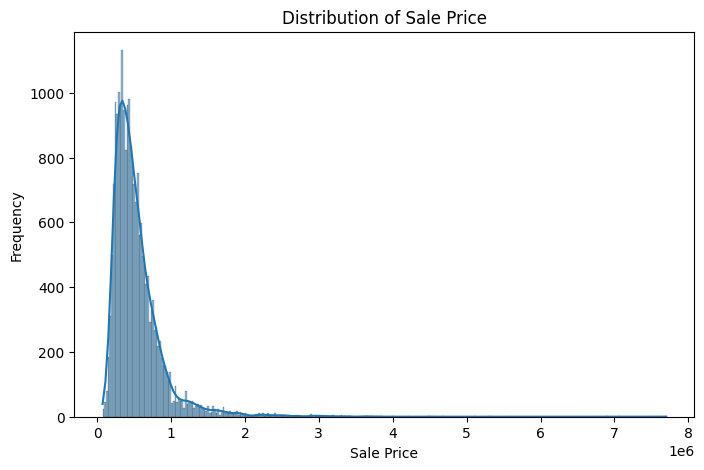

In [114]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Sale Price"],
    kde=True
)

plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Distribution of Sale Price")

plt.show()

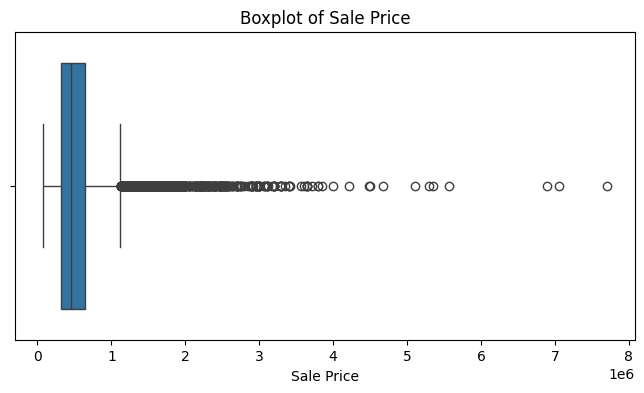

In [115]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["Sale Price"]
)

plt.xlabel("Sale Price")
plt.title("Boxplot of Sale Price")

plt.show()

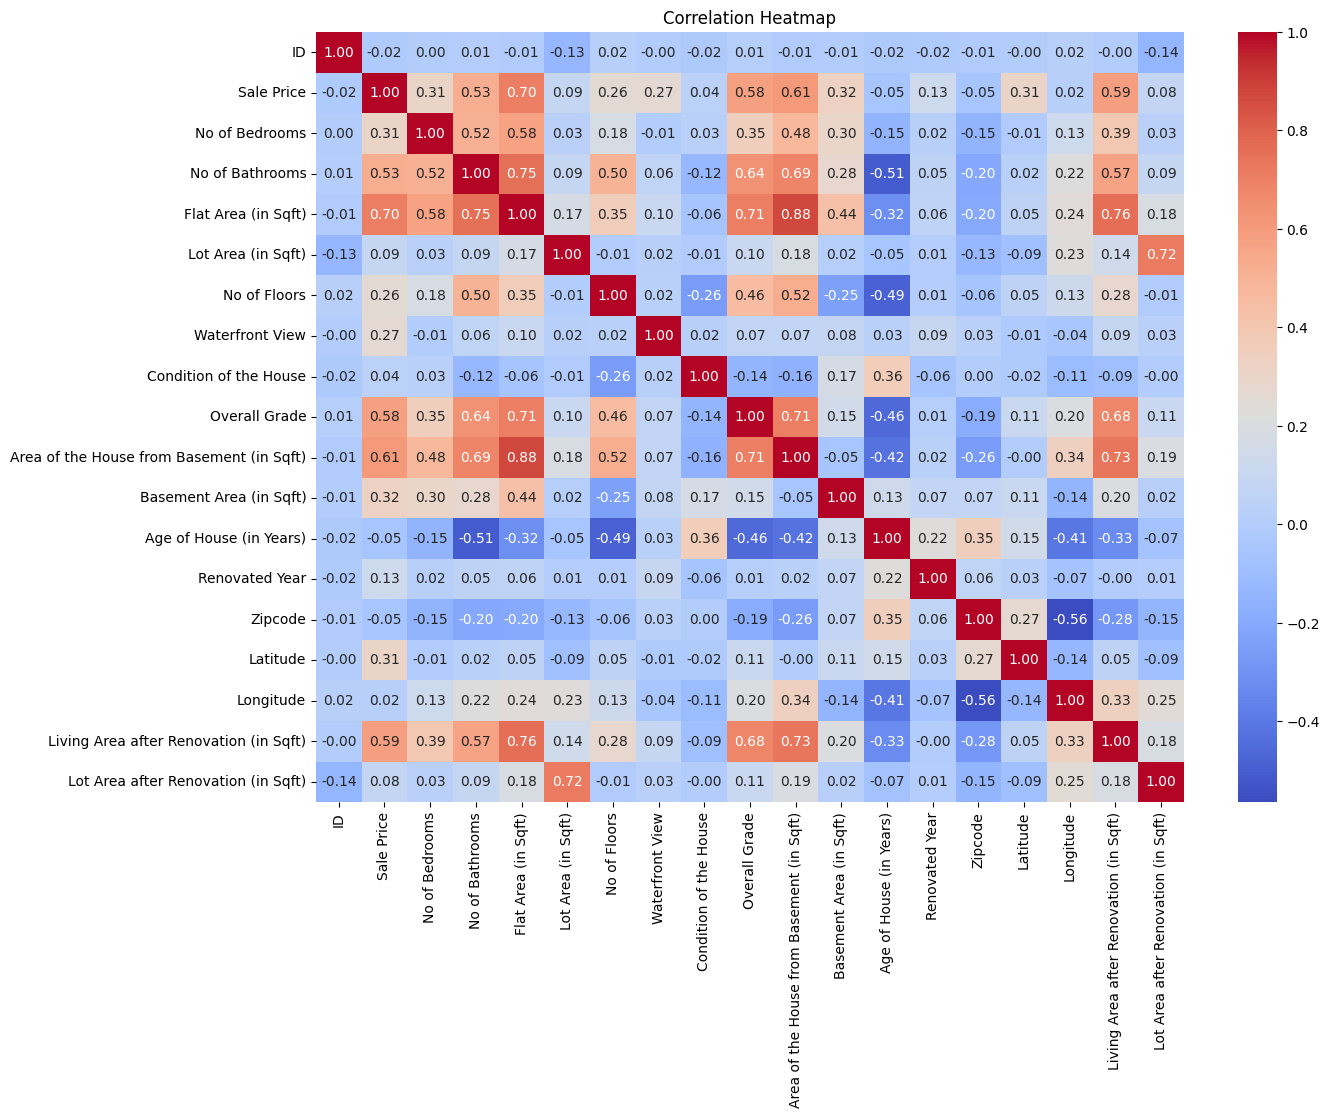

In [116]:
plt.figure(figsize=(14, 10))

correlation = df.select_dtypes(
    include=["int64", "float64"]
).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

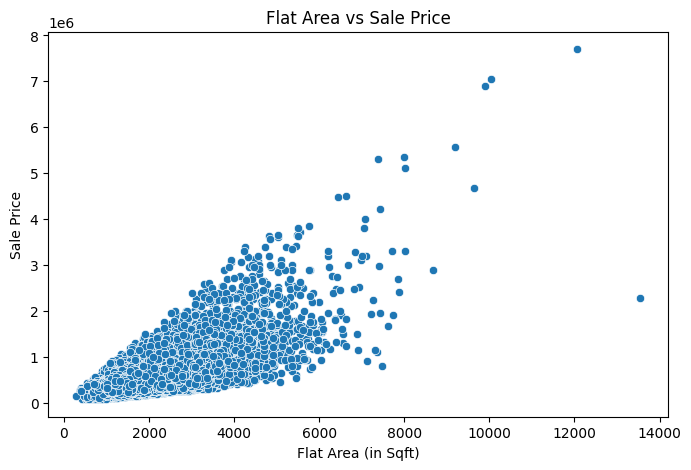

In [117]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Flat Area (in Sqft)",
    y="Sale Price",
    data=df
)

plt.xlabel("Flat Area (in Sqft)")
plt.ylabel("Sale Price")
plt.title("Flat Area vs Sale Price")

plt.show()

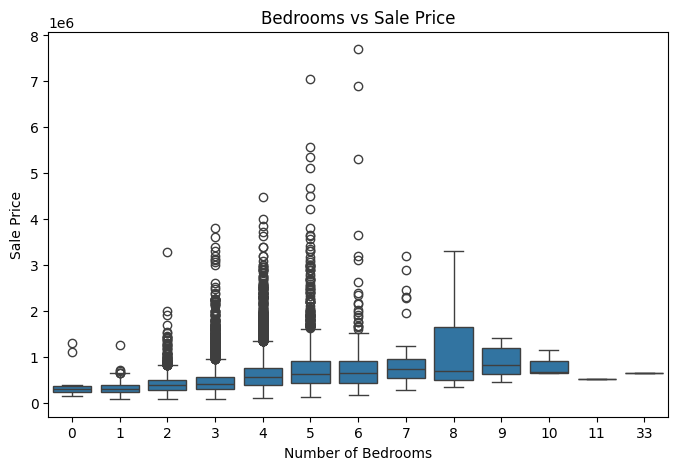

In [118]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="No of Bedrooms",
    y="Sale Price",
    data=df
)

plt.xlabel("Number of Bedrooms")
plt.ylabel("Sale Price")
plt.title("Bedrooms vs Sale Price")

plt.show()

# **Target Identified**

In [76]:
target_data = df["Sale Price"]


# Extracting target data's name
target = target_data.name

#**Train-Test**

In [77]:
df.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [78]:
df = df.dropna(subset=["Sale Price"])

In [79]:
target = "Sale Price"

X = df.drop(columns=[target])
y = df[target]

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (17287, 20)
Testing data: (4322, 20)


#**Handling Missing Values**

In [81]:
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

Missing values in X_train:
ID                                               0
Date House was Sold                              0
No of Bedrooms                                   0
No of Bathrooms                                  4
Flat Area (in Sqft)                              5
Lot Area (in Sqft)                               9
No of Floors                                     0
Waterfront View                                  0
No of Times Visited                          15629
Condition of the House                           0
Overall Grade                                    0
Area of the House from Basement (in Sqft)        2
Basement Area (in Sqft)                          0
Age of House (in Years)                          0
Renovated Year                                   0
Zipcode                                          0
Latitude                                         1
Longitude                                        1
Living Area after Renovation (in Sqft)           1
Lot 

In [82]:
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
Index(['ID', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

Categorical columns:
Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')


In [89]:
# Flat Area
flat_area_mean = X_train["Flat Area (in Sqft)"].mean()

X_train["Flat Area (in Sqft)"] = X_train["Flat Area (in Sqft)"].fillna(
    flat_area_mean
)

X_test["Flat Area (in Sqft)"] = X_test["Flat Area (in Sqft)"].fillna(
    flat_area_mean
)


# Lot Area
lot_area_mean = X_train["Lot Area (in Sqft)"].mean()

X_train["Lot Area (in Sqft)"] = X_train["Lot Area (in Sqft)"].fillna(
    lot_area_mean
)

X_test["Lot Area (in Sqft)"] = X_test["Lot Area (in Sqft)"].fillna(
    lot_area_mean
)

In [90]:
# No of Bathrooms
bathroom_median = X_train["No of Bathrooms"].median()

X_train["No of Bathrooms"] = X_train["No of Bathrooms"].fillna(
    bathroom_median
)

X_test["No of Bathrooms"] = X_test["No of Bathrooms"].fillna(
    bathroom_median
)

In [91]:
# Area of the House from Basement
basement_median = X_train[
    "Area of the House from Basement (in Sqft)"
].median()

X_train["Area of the House from Basement (in Sqft)"] = X_train[
    "Area of the House from Basement (in Sqft)"
].fillna(
    basement_median
)

X_test["Area of the House from Basement (in Sqft)"] = X_test[
    "Area of the House from Basement (in Sqft)"
].fillna(
    basement_median
)

In [92]:
# Zipcode
zipcode_median = X_train["Zipcode"].median()

X_train["Zipcode"] = X_train["Zipcode"].fillna(
    zipcode_median
)

X_test["Zipcode"] = X_test["Zipcode"].fillna(
    zipcode_median
)

In [93]:
# Latitude
latitude_median = X_train["Latitude"].median()

X_train["Latitude"] = X_train["Latitude"].fillna(
    latitude_median
)

X_test["Latitude"] = X_test["Latitude"].fillna(
    latitude_median
)

In [94]:
# Longitude
longitude_median = X_train["Longitude"].median()

X_train["Longitude"] = X_train["Longitude"].fillna(
    longitude_median
)

X_test["Longitude"] = X_test["Longitude"].fillna(
    longitude_median
)

In [95]:
# Living Area after Renovation
renovation_median = X_train[
    "Living Area after Renovation (in Sqft)"
].median()

X_train["Living Area after Renovation (in Sqft)"] = X_train[
    "Living Area after Renovation (in Sqft)"
].fillna(
    renovation_median
)

X_test["Living Area after Renovation (in Sqft)"] = X_test[
    "Living Area after Renovation (in Sqft)"
].fillna(
    renovation_median
)

In [96]:
categorical_cols = X_train.select_dtypes(
    include="object"
).columns

print(categorical_cols)

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')


In [97]:
for col in categorical_cols:

    mode_value = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode_value)

    X_test[col] = X_test[col].fillna(mode_value)

In [98]:
print("Total missing values in X_train:",
      X_train.isnull().sum().sum())

print("Total missing values in X_test:",
      X_test.isnull().sum().sum())

Total missing values in X_train: 0
Total missing values in X_test: 0


#**Encoding**

In [99]:
print(X_train.select_dtypes(include="object").columns)

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')


In [100]:
X_train["Date House was Sold"] = pd.to_datetime(
    X_train["Date House was Sold"]
)

X_test["Date House was Sold"] = pd.to_datetime(
    X_test["Date House was Sold"]
)

X_train["Sale_Year"] = X_train["Date House was Sold"].dt.year
X_train["Sale_Month"] = X_train["Date House was Sold"].dt.month

X_test["Sale_Year"] = X_test["Date House was Sold"].dt.year
X_test["Sale_Month"] = X_test["Date House was Sold"].dt.month

X_train.drop(columns=["Date House was Sold"], inplace=True)
X_test.drop(columns=["Date House was Sold"], inplace=True)

In [101]:
le = LabelEncoder()

X_train["Waterfront View"] = le.fit_transform(
    X_train["Waterfront View"]
)

X_test["Waterfront View"] = le.transform(
    X_test["Waterfront View"]
)

In [102]:
condition_encoder = OrdinalEncoder(
    categories=[[
        "Bad",
        "Okay",
        "Fair",
        "Good",
        "Excellent"
    ]]
)

X_train[["Condition of the House"]] = condition_encoder.fit_transform(
    X_train[["Condition of the House"]]
)

X_test[["Condition of the House"]] = condition_encoder.transform(
    X_test[["Condition of the House"]]
)

In [103]:
visited_encoder = OrdinalEncoder(
    categories=[[
        "Once",
        "Twice",
        "Thrice",
        "Four"
    ]]
)

X_train[["No of Times Visited"]] = visited_encoder.fit_transform(
    X_train[["No of Times Visited"]]
)

X_test[["No of Times Visited"]] = visited_encoder.transform(
    X_test[["No of Times Visited"]]
)

In [104]:
categorical_cols = X_train.select_dtypes(include="object").columns

print(categorical_cols)

Index([], dtype='object')


#**Outlier**

In [105]:
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

print(numeric_cols)

Index(['ID', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Waterfront View',
       'No of Times Visited', 'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


In [106]:
for col in numeric_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = X_train[
        (X_train[col] < lower_limit) |
        (X_train[col] > upper_limit)
    ]

    print(col, ":", len(outliers), "outliers")

ID : 0 outliers
No of Bedrooms : 454 outliers
No of Bathrooms : 215 outliers
Flat Area (in Sqft) : 461 outliers
Lot Area (in Sqft) : 1961 outliers
No of Floors : 0 outliers
Waterfront View : 123 outliers
No of Times Visited : 901 outliers
Condition of the House : 19 outliers
Overall Grade : 1481 outliers
Area of the House from Basement (in Sqft) : 509 outliers
Basement Area (in Sqft) : 453 outliers
Age of House (in Years) : 0 outliers
Renovated Year : 722 outliers
Zipcode : 0 outliers
Latitude : 1 outliers
Longitude : 202 outliers
Living Area after Renovation (in Sqft) : 396 outliers
Lot Area after Renovation (in Sqft) : 1768 outliers


In [107]:
outlier_mask = pd.Series(True, index=X_train.index)

for col in numeric_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outlier_mask = outlier_mask & (
        (X_train[col] >= lower_limit) &
        (X_train[col] <= upper_limit)
    )

In [108]:
X_train = X_train[outlier_mask]
y_train = y_train.loc[outlier_mask]

In [109]:
scaler = StandardScaler()

In [110]:
X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

In [111]:
X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [113]:
X_train.head()

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale_Year,Sale_Month
7095,1.341822,-0.346729,0.787742,0.316715,0.421522,0.954554,0.0,0.0,0.888044,1.957963,0.712716,-0.660768,-0.128976,0.0,-1.359170,0.475797,1.126423,1.233928,0.408419,2017,5
18538,1.111347,-0.346729,-1.493284,-0.953760,0.010822,-0.868047,0.0,0.0,-0.654050,-0.491815,-0.828785,-0.267390,1.597229,0.0,0.651989,0.083414,-1.273078,-0.815483,-0.337833,2017,10
20023,-1.552690,-0.346729,0.407571,-0.555148,-1.240948,0.954554,0.0,0.0,-0.654050,-0.491815,-0.187586,-0.660768,-1.381321,0.0,-1.470901,-1.521593,0.134087,-0.639543,-1.272138,2017,6
6254,-1.125025,2.220914,1.928256,2.365355,1.298357,0.954554,0.0,0.0,0.888044,0.733074,1.450670,1.699501,-0.941308,0.0,-0.726027,-1.204423,0.646523,1.001920,0.486222,2017,7
15383,-1.601180,0.937092,0.787742,0.435822,-0.265462,0.954554,0.0,0.0,-0.654050,0.733074,0.835709,-0.660768,-1.076697,0.0,-0.726027,-1.469086,0.703460,0.228557,0.381270,2017,7


In [119]:
print("Rows before outlier removal:", len(outlier_mask))
print("Rows after outlier removal:", X_train.shape[0])

Rows before outlier removal: 17287
Rows after outlier removal: 12515


In [120]:
print("X_train rows:", X_train.shape[0])
print("y_train rows:", y_train.shape[0])

X_train rows: 12515
y_train rows: 12515
